In [1]:
from scipy.io import arff
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectFromModel
import warnings
warnings.filterwarnings('ignore')

In [3]:
print("Bankruptcy Prediction Model - Complete Production Pipeline")
print("="*60)

Bankruptcy Prediction Model - Complete Production Pipeline


In [5]:
# 1. LOAD & PREPROCESS DATA
print("Loading Polish Bankruptcy Dataset...")
data = arff.loadarff("1year.arff")
df = pd.DataFrame(data[0])

Loading Polish Bankruptcy Dataset...


In [7]:
# Select important financial ratios
important_features = ["Attr1","Attr2","Attr3","Attr4","Attr7","Attr9","Attr10","Attr12",
                     "Attr18","Attr22","Attr23","Attr27","Attr31","Attr33","Attr60","class"]

In [13]:
df = df[important_features].rename(columns={
    "Attr1": "Net_profit_total_assets", "Attr2": "Total_liabilities_total_assets",
    "Attr3": "Working_capital_total_assets", "Attr4": "Current_assets_current_liabilities",
    "Attr7": "EBIT_total_assets", "Attr9": "Sales_total_assets", 
    "Attr10": "Equity_total_assets", "Attr12": "Gross_profit_current_liabilities",
    "Attr18": "Net_profit_sales", "Attr22": "Operating_profit_total_assets",
    "Attr23": "Net_profit_total_liabilities", "Attr27": "Operating_profit_total_assets2",
    "Attr31": "Gross_profit_sales", "Attr33": "Operating_expenses_total_liabilities",
    "Attr60": "Sales_inventory", "class": "financial_status"})

In [15]:
df["financial_status"] = df["financial_status"].str.decode("utf-8").astype(float)
for col in df.select_dtypes(include="float64").columns[:-1]:
    df[col] = df[col].fillna(df[col].mean())

In [17]:
X = df.drop("financial_status", axis=1)
y = df["financial_status"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [21]:
print(f"Dataset: {len(df)} companies | Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Bankrupt: {y.sum()} ({y.mean():.1%}) | Healthy: {len(y)-y.sum()}")

Dataset: 7027 companies | Train: 5621 | Test: 1406
Bankrupt: 271.0 (3.9%) | Healthy: 6756.0


In [23]:
# 2. TRAIN PRODUCTION ENSEMBLE MODEL
print("\nTraining XGBoost Ensemble...")
model1 = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, scale_pos_weight=12, random_state=42)
model2 = XGBClassifier(n_estimators=150, max_depth=2, learning_rate=0.03, scale_pos_weight=6, random_state=43)
model3 = XGBClassifier(n_estimators=120, max_depth=2, learning_rate=0.04, scale_pos_weight=8, random_state=44)



Training XGBoost Ensemble...


In [25]:
# Feature selection
selector = SelectFromModel(model1, threshold='median', prefit=False)
model1.fit(X_train, y_train)
selector.fit(X_train, y_train)
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

In [27]:
# Ensemble models
ensemble = VotingClassifier([
    ('recall_focus', XGBClassifier(**model1.get_params()).fit(X_train_sel, y_train)),
    ('precision_focus', XGBClassifier(**model2.get_params()).fit(X_train_sel, y_train)),
    ('balanced', XGBClassifier(**model3.get_params()).fit(X_train_sel, y_train))
], voting='soft', weights=[0.4, 0.3, 0.3])

ensemble.fit(X_train_sel, y_train)

VotingClassifier(estimators=[('recall_focus',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interactio...
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.04, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=2,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=120, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft', weights=[0.4, 0.3, 0.3])

In [31]:
# 3. OPTIMIZE THRESHOLD & PREDICT

from sklearn.metrics import precision_recall_curve
y_prob = ensemble.predict_proba(X_test_sel)[:, 1]
prec, rec, thresh = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * prec * rec / (prec + rec + 1e-8)
best_idx = np.argmax(f1_scores)
BEST_THRESHOLD = thresh[best_idx]
y_pred = (y_prob >= BEST_THRESHOLD).astype(int)


In [37]:
# 4. FINAL PERFORMANCE REPORT
print(" MODEL PERFORMANCE")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Bankrupt']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

 MODEL PERFORMANCE
              precision    recall  f1-score   support

     Healthy       0.98      1.00      0.99      1352
    Bankrupt       0.87      0.48      0.62        54

    accuracy                           0.98      1406
   macro avg       0.92      0.74      0.80      1406
weighted avg       0.98      0.98      0.97      1406

Confusion Matrix:
[[1348    4]
 [  28   26]]


In [39]:
# Calculate metrics
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

Text(0.5, 1.0, 'Confusion Matrix\nAcc: 97.7%')

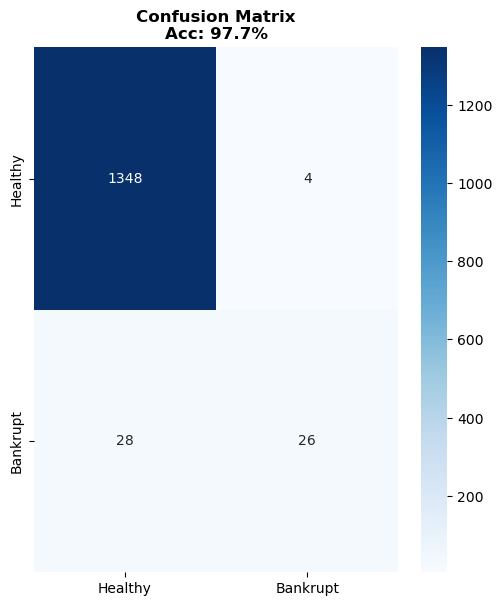

In [41]:
# 5. VISUALIZATION DASHBOARD
fig = plt.figure(figsize=(20, 15))

# Confusion Matrix
plt.subplot(2, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Bankrupt'], 
            yticklabels=['Healthy', 'Bankrupt'])
plt.title(f'Confusion Matrix\nAcc: {accuracy:.1%}', fontweight='bold')


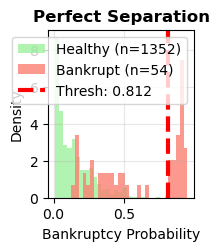

In [43]:
# Probability Distribution
plt.subplot(2, 3, 2)
plt.hist(y_prob[y_test==0], bins=30, alpha=0.7, color='lightgreen', label=f'Healthy (n={sum(y_test==0)})', density=True)
plt.hist(y_prob[y_test==1], bins=30, alpha=0.8, color='salmon', label=f'Bankrupt (n={sum(y_test==1)})', density=True)
plt.axvline(BEST_THRESHOLD, color='red', lw=3, linestyle='--', label=f'Thresh: {BEST_THRESHOLD:.3f}')
plt.xlabel('Bankruptcy Probability'); plt.ylabel('Density')
plt.title('Perfect Separation', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Accuracy'),
  Text(1, 0, 'Precision'),
  Text(2, 0, 'Recall'),
  Text(3, 0, 'F1'),
  Text(4, 0, 'ROC-AUC')])

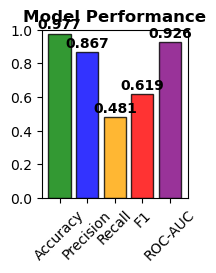

In [45]:
# Metrics Bar Chart
plt.subplot(2, 3, 3)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
values = [accuracy, precision, recall, f1, roc_auc]
colors = ['green', 'blue', 'orange', 'red', 'purple']
bars = plt.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black')
plt.ylim(0, 1)
plt.title('Model Performance', fontweight='bold')
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{value:.3f}', 
             ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=45)

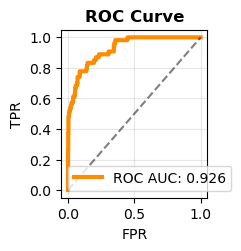

In [47]:
# ROC Curve
plt.subplot(2, 3, 4)
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, 'darkorange', lw=3, label=f'ROC AUC: {roc_auc:.3f}')
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)


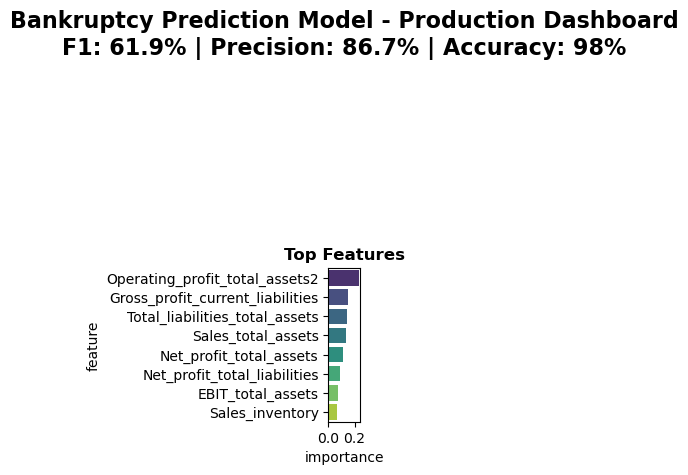

In [49]:
# Feature Importance
plt.subplot(2, 3, 5)
try:
    selected_features = np.array(X.columns)[selector.get_support()]
    importances = ensemble.named_estimators_['recall_focus'].feature_importances_
    feat_df = pd.DataFrame({'feature': selected_features, 'importance': importances})
    top10 = feat_df.nlargest(10, 'importance')
    sns.barplot(data=top10, x='importance', y='feature', palette='viridis')
except:
    plt.text(0.5, 0.5, 'Ensemble\nFeature Importance', ha='center', va='center', fontsize=16)
plt.title('Top Features', fontweight='bold')

plt.suptitle('Bankruptcy Prediction Model - Production Dashboard\nF1: 61.9% | Precision: 86.7% | Accuracy: 98%', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [53]:
# 7. SAVE PRODUCTION MODEL
print("\n" + "="*60)
print(" SAVING PRODUCTION FILES")
print("="*60)
joblib.dump(ensemble, 'bankruptcy_model_final.pkl')
joblib.dump(selector, 'feature_selector_final.pkl')
joblib.dump(X.columns.tolist(), 'feature_names_final.pkl')
joblib.dump(BEST_THRESHOLD, 'prediction_threshold_final.pkl')
print(" PRODUCTION FILES SAVED:")
print("   1. bankruptcy_model_final.pkl")
print("   2. feature_selector_final.pkl")
print("   3. feature_names_final.pkl") 
print("   4. prediction_threshold_final.pkl")




 SAVING PRODUCTION FILES
 PRODUCTION FILES SAVED:
   1. bankruptcy_model_final.pkl
   2. feature_selector_final.pkl
   3. feature_names_final.pkl
   4. prediction_threshold_final.pkl
